# MIMO Convolution — Single-Shot Multiplexed Packing (Orion 4.2–4.3) / OpenFHE



## Kurulum

OpenFHE için Python 3.10 ortamını kuruyorum

In [1]:
# ortami kuruyorum (python 3.10 + openfhe) -- SISO ile birebir ayni
!pip install -q uv
!uv python install 3.10
!uv venv /content/fhe310 --python 3.10
!uv pip install --python /content/fhe310/bin/python "openfhe==1.5.1.0.22.4" numpy scipy
!/content/fhe310/bin/python -c "import openfhe, sys; print('OpenFHE hazir, Python', sys.version.split()[0])"

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 22.3/22.3 MB 38.8 MB/s eta 0:00:00
Installed Python 3.10.20 in 1.17s
 + cpython-3.10.20-linux-x86_64-gnu (python3.10)
Using CPython 3.10.20
Creating virtual environment at: fhe310
Activate with: source fhe310/bin/activate
Using Python 3.10.20 environment at: fhe310
Resolved 3 packages in 974ms
Prepared 3 packages in 1.51s
Installed 3 packages in 28ms
 + numpy==2.2.6
 + openfhe==1.5.1.0.22.4
 + scipy==1.15.3
OpenFHE hazir, Python 3.10.20


## Yöntem

**MIMO Toeplitz (§4.2).** $C_i$ girdi ve $C_o$ çıktı kanalı için convolution $y = T\,x$ olarak yazılır. $x$, tüm girdi kanalları uç uca eklenmiş düz vektör; $T$ ise blok-Toeplitz: $(c_o,c_i)$ bloğu, o filtrenin SISO Toeplitz'idir. Tek büyük matris → tek matvec → **depth 1**.

**Single-shot multiplexed (§4.3).** Stride $s$ olduğunda standart Toeplitz'in diagonalleri seyrekleşir (Fig. 4a, *maximal non-zero diagonals*). Orion, satırları permüte ederek (output gap $g = s$) çıktıyı `pixel_shuffle` ile **multiplexed** yerleşime sokar: çıktı pikseli $(o_h,o_w)$ kanal $c_o$ için slot

$$\text{mrow}=o_h\cdot s + (c_o \bmod s^2)//s,\quad \text{mcol}=o_w\cdot s + (c_o \bmod s^2)\bmod s.$$

Bu permütasyon ardışık satırların kernel'i 1 kaydırmasını sağlar; her filtre elemanı aynı diagonalde kalır → **minimal non-zero diagonals** (Fig. 4b). Padding sütunlarının atılması ve bu satır permütasyonu birlikte **mask-and-collect adımını ağırlığa gömer**, dolayısıyla ikinci bir çarpım gerekmez.

**CKKS ayarları .** MultiplicativeDepth = 1, ScalingModSize = 50 (≈50-bit hassasiyet), BatchSize = S (kareye gömülen matrisin üzerindeki 2'nin kuvveti). OpenFHE ring boyutunu 128-bit güvenlik için kendisi seçer.

**Rotasyon (KSO) optimizasyonu.** Düz diagonal yöntemde rotasyon = (sıfır-olmayan diagonal − 1). BSGS'te $k = n_1 j + i$ ayrımıyla baby rotasyonları paylaşılır; rotasyon ≈ $O(\sqrt{\cdot})$'e iner, **depth yine 1** kalır (her terim tek plaintext çarpımı).

## FHE kodu

Tüm mantığı tek script'e yazıyorum: SISO Toeplitz kurucusu, MIMO blok-Toeplitz (baseline), Orion multiplexed Toeplitz, (de)multiplex, diagonal çıkarma, BSGS planlayıcı ve depth-1 FHE matvec (plain + BSGS).

In [2]:
%%writefile /content/mimo_mux_fhe.py
# MIMO + Single-Shot Multiplexed (Orion 4.2-4.3) convolution -- OpenFHE / CKKS (CPU)
# SISO Toeplitz+diagonal altyapisinin cok-kanalli (MIMO) ve Orion multiplexed reordering'e
# genisletilmis hali. Mask-and-collect adimi agirlik matrisine on-islemle gomuldugu icin
# tum strided convolution multiplicative depth = 1'de kalir; reordering rotasyon sayisini minimize eder.
import argparse, json, os, math, time
import numpy as np

OUT = "/content"
os.makedirs(OUT, exist_ok=True)

# OpenFHE sadece FHE calistiginda import edilir (sanity/plan FHE'siz calisir)
def _import_fhe():
    from openfhe import CCParamsCKKSRNS, GenCryptoContext, PKE, KEYSWITCH, LEVELEDSHE
    return CCParamsCKKSRNS, GenCryptoContext, PKE, KEYSWITCH, LEVELEDSHE

# ----------------------------------------------------------------------
# 1) SISO Toeplitz (referans SISO kodundan birebir) ve MIMO block-Toeplitz
# ----------------------------------------------------------------------
def build_toeplitz_siso(H_in, W_in, kernel, stride=1, padding=0, dilation=1):
    sH = sW = stride; pH = pW = padding; dH = dW = dilation
    kH, kW = kernel.shape
    H_pad, W_pad = H_in + 2*pH, W_in + 2*pW
    eff_kH = (kH-1)*dH + 1; eff_kW = (kW-1)*dW + 1
    H_out = (H_pad - eff_kH)//sH + 1; W_out = (W_pad - eff_kW)//sW + 1
    idx = -np.ones((H_pad, W_pad), int)
    idx[pH:pH+H_in, pW:pW+W_in] = np.arange(H_in*W_in).reshape(H_in, W_in)
    T = np.zeros((H_out*W_out, H_in*W_in))
    for oh in range(H_out):
        for ow in range(W_out):
            r = oh*W_out + ow
            for kh in range(kH):
                for kw in range(kW):
                    s = idx[oh*sH + kh*dH, ow*sW + kw*dW]
                    if s >= 0: T[r, s] += kernel[kh, kw]
    return T, (H_out, W_out)

def build_mimo_block_toeplitz(Ci, Hi, Wi, Co, weight, stride, padding, dilation=1):
    """Figure 3 / 4a: cikti kanallari satir bloklarina, girdi kanallari sutun bloklarina.
    y[co] = sum_ci T[co,ci] @ x[ci]. Tek buyuk matris -> tek matvec -> depth 1."""
    _, (Ho, Wo) = build_toeplitz_siso(Hi, Wi, weight[0, 0], stride, padding, dilation)
    T = np.zeros((Co*Ho*Wo, Ci*Hi*Wi))
    for co in range(Co):
        for ci in range(Ci):
            Tb, _ = build_toeplitz_siso(Hi, Wi, weight[co, ci], stride, padding, dilation)
            T[co*Ho*Wo:(co+1)*Ho*Wo, ci*Hi*Wi:(ci+1)*Hi*Wi] = Tb
    return T, (Ho, Wo)

# ----------------------------------------------------------------------
# 2) Orion single-shot multiplexed Toeplitz (4.3). Satir permutasyonu (row-interchange)
#    + mask-and-collect'in agirliga gomulmesi. iG=1 (ilk katman) durumunda girdi normal.
# ----------------------------------------------------------------------
def build_mux_toeplitz(Ci, Hi, Wi, Co, weight, stride, padding, dilation=1, iG=1):
    kH, kW = weight.shape[2], weight.shape[3]; D = dilation; P = padding
    oG = iG*stride
    Ho = (Hi + 2*P - ((kH-1)*D+1))//stride + 1
    Wo = (Wi + 2*P - ((kW-1)*D+1))//stride + 1
    on_Ci = math.ceil(Ci/(iG**2)); on_Hi = Hi*iG; on_Wi = Wi*iG
    on_Co = math.ceil(Co/(oG**2)); on_Ho = Ho*oG; on_Wo = Wo*oG
    Hi_pad = on_Hi + 2*P*iG; Wi_pad = on_Wi + 2*P*iG
    n_rows = on_Co*on_Ho*on_Wo; n_cols = on_Ci*Hi_pad*Wi_pad
    vii = np.arange(n_cols).reshape(on_Ci, Hi_pad, Wi_pad)
    # kanal sayilari gap^2'ye tamamlanir (pixel-shuffle multiplexing icin)
    kernel = np.zeros((on_Co*oG**2, on_Ci*iG**2, kH, kW))
    kernel[:Co, :Ci] = weight
    # ilk kernel pozisyonunun dokundugu girdi pikselleri
    mpx = vii[:, :iG, :iG].reshape(-1, 1)
    ri = np.arange(0, kH*D*iG, D*iG).reshape(-1, 1)
    ci = np.arange(0, kW*D*iG, D*iG)
    koff = vii[0][ri, ci].flatten()
    ikp = (mpx + koff).flatten()
    # satir-degisim haritasi (multiplexed cikti yerlesimi)
    oi = np.arange(on_Ho*on_Wo).reshape(on_Ho, on_Wo)
    start = oi[:oG, :oG].flatten()
    corner = oi[0:Ho*oG:oG, 0:Wo*oG:oG].reshape(-1, 1)
    row_map = corner + start
    corner_img = vii[0, 0:Ho*oG:oG, 0:Wo*oG:oG].flatten()
    out_ch = (np.arange(on_Co)*(on_Ho*on_Wo)).reshape(on_Co, 1)
    kflat = kernel.reshape(kernel.shape[0], -1)
    T = np.zeros((n_rows, n_cols))
    for i, sidx in enumerate(corner_img):
        rows = (row_map[i] + out_ch).reshape(-1, 1)
        cols = ikp + sidx
        T[rows, cols] = kflat
    # padding sutunlarini at (mask-and-collect'in agirliga gomulmesi)
    ri2 = np.arange(P*iG, P*iG + on_Hi).reshape(-1, 1)
    ci2 = np.arange(P*iG, P*iG + on_Wi)
    img_idx = vii[:, ri2, ci2].flatten()
    T = T[:, img_idx]
    return T, (on_Co, on_Ho, on_Wo), (Ho, Wo, oG)

def demultiplex(vec, on_Co, on_Ho, on_Wo, Co, Ho, Wo, oG):
    """Ters pixel-shuffle: multiplexed cikti -> (Co, Ho, Wo)."""
    t = np.asarray(vec).reshape(on_Co, on_Ho, on_Wo)
    out = np.zeros((on_Co*oG**2, Ho, Wo))
    for c in range(on_Co):
        for a in range(oG):
            for b in range(oG):
                out[c*oG**2 + a*oG + b] = t[c, a::oG, b::oG]
    return out[:Co]

# ----------------------------------------------------------------------
# 3) Plaintext referans convolution (correlation, SISO ile ayni konvansiyon)
# ----------------------------------------------------------------------
def conv_ref(x, weight, stride, padding, dilation=1):
    Ci, Hi, Wi = x.shape; Co = weight.shape[0]; kH, kW = weight.shape[2:]
    xp = np.pad(x, ((0, 0), (padding, padding), (padding, padding)))
    eff_kH = (kH-1)*dilation + 1; eff_kW = (kW-1)*dilation + 1
    Ho = (Hi + 2*padding - eff_kH)//stride + 1
    Wo = (Wi + 2*padding - eff_kW)//stride + 1
    o = np.zeros((Co, Ho, Wo))
    for co in range(Co):
        for oh in range(Ho):
            for ow in range(Wo):
                acc = 0.0
                for ci in range(Ci):
                    for kh in range(kH):
                        for kw in range(kW):
                            acc += xp[ci, oh*stride + kh*dilation, ow*stride + kw*dilation]*weight[co, ci, kh, kw]
                o[co, oh, ow] = acc
    return o

# ----------------------------------------------------------------------
# 4) Diagonal cikarma + BSGS planlama
# ----------------------------------------------------------------------
def next_pow2(n):
    p = 1
    while p < n: p *= 2
    return p

def nonzero_diagonals(T, S):
    R, C = T.shape
    M = np.zeros((S, S)); M[:R, :C] = T
    base = np.arange(S); diags = {}
    for k in range(S):
        d = M[base, (base + k) % S]
        if np.any(d != 0): diags[k] = d
    return diags

def plan_bsgs(diag_keys, S):
    """En az rotasyon veren baby-step boyutu n1'i sec. Depth = 1 korunur."""
    keys = sorted(diag_keys)
    best = None
    for n1 in range(1, S + 1):
        baby = set(k % n1 for k in keys)
        giant = set(k // n1 for k in keys)
        rot = len(baby - {0}) + len(giant - {0})
        if best is None or rot < best[0]:
            best = (rot, n1, baby, giant)
    return best  # (rot, n1, baby_set, giant_set)

# ----------------------------------------------------------------------
# 5) CKKS baglami ve FHE matvec (plain + BSGS), her ikisi de depth 1
# ----------------------------------------------------------------------
def build_cc(S, depth=1, scale=50):
    CCParamsCKKSRNS, GenCryptoContext, PKE, KEYSWITCH, LEVELEDSHE = _import_fhe()
    p = CCParamsCKKSRNS()
    p.SetMultiplicativeDepth(depth)
    p.SetScalingModSize(scale)
    p.SetBatchSize(S)
    cc = GenCryptoContext(p)
    cc.Enable(PKE); cc.Enable(KEYSWITCH); cc.Enable(LEVELEDSHE)
    return cc

def he_matvec_plain(cc, keys, x_vec, diag_pts, S, repeats=3):
    times = []; ct_final = None
    for _ in range(max(1, repeats)):
        xp = np.zeros(S); xp[:len(x_vec)] = x_vec
        ct_x = cc.Encrypt(keys.publicKey, cc.MakeCKKSPackedPlaintext(list(xp)))
        t0 = time.perf_counter(); ct_acc = None
        for k, pt in diag_pts.items():
            ct_rot = ct_x if k == 0 else cc.EvalRotate(ct_x, k)
            part = cc.EvalMult(ct_rot, pt)
            ct_acc = part if ct_acc is None else cc.EvalAdd(ct_acc, part)
        times.append(time.perf_counter() - t0); ct_final = ct_acc
    return ct_final, float(np.mean(times)), float(np.std(times))

def he_matvec_bsgs(cc, keys, x_vec, diags, S, n1, repeats=3):
    # k = n1*j + i ; baby: rot(ct, i) ; giant: rot(inner_j, n1*j). Plaintext diagonal roll(d, n1*j).
    grouped = {}  # j -> list of (i, plaintext)
    for k, d in diags.items():
        j, i = k // n1, k % n1
        pt = cc.MakeCKKSPackedPlaintext(list(np.roll(d, n1*j)))
        grouped.setdefault(j, []).append((i, pt))
    baby_idx = sorted({i for terms in grouped.values() for (i, _) in terms} - {0})
    times = []; ct_final = None
    for _ in range(max(1, repeats)):
        xp = np.zeros(S); xp[:len(x_vec)] = x_vec
        ct_x = cc.Encrypt(keys.publicKey, cc.MakeCKKSPackedPlaintext(list(xp)))
        t0 = time.perf_counter()
        babies = {0: ct_x}
        for i in baby_idx:
            babies[i] = cc.EvalRotate(ct_x, i)
        acc = None
        for j, terms in grouped.items():
            inner = None
            for (i, pt) in terms:
                part = cc.EvalMult(babies[i], pt)
                inner = part if inner is None else cc.EvalAdd(inner, part)
            rot = inner if j == 0 else cc.EvalRotate(inner, n1*j)
            acc = rot if acc is None else cc.EvalAdd(acc, rot)
        times.append(time.perf_counter() - t0); ct_final = acc
    return ct_final, float(np.mean(times)), float(np.std(times))

# ----------------------------------------------------------------------
# 6) Deney kosucusu
# ----------------------------------------------------------------------
def run_experiment(name, x, weight, stride, padding, dilation=1, method="both",
                   atol=5e-2, repeats=3, save_prefix=None, do_fhe=True):
    Ci, Hi, Wi = x.shape; Co = weight.shape[0]
    expected = conv_ref(x, weight, stride, padding, dilation)
    Ho, Wo = expected.shape[1], expected.shape[2]
    # baseline MIMO block-Toeplitz (Fig 3 / 4a) -- sadece diagonal sayimi icin
    T_base, _ = build_mimo_block_toeplitz(Ci, Hi, Wi, Co, weight, stride, padding, dilation)
    S_base = next_pow2(max(T_base.shape))
    base_diags = nonzero_diagonals(T_base, S_base)
    # multiplexed (Fig 4b)
    T_mux, (oC, oH, oW), (Ho2, Wo2, oG) = build_mux_toeplitz(Ci, Hi, Wi, Co, weight, stride, padding, dilation)
    S = next_pow2(max(T_mux.shape))
    mux_diags = nonzero_diagonals(T_mux, S)
    mux_keys = sorted(mux_diags.keys())
    bsgs_rot, n1, _, _ = plan_bsgs(mux_keys, S)
    plain_rot = len(mux_keys) - (1 if 0 in mux_diags else 0)

    r = dict(name=name, input_shape=[Ci, Hi, Wi], output_shape=[Co, Ho, Wo],
             mux_output_shape=[oC, oH, oW], output_gap=oG, slots=S,
             baseline_toeplitz_shape=list(T_base.shape), baseline_diagonals=len(base_diags),
             baseline_rotations=len(base_diags) - (1 if 0 in base_diags else 0),
             mux_toeplitz_shape=list(T_mux.shape), mux_diagonals=len(mux_diags),
             plain_rotations=plain_rot, bsgs_rotations=bsgs_rot, bsgs_n1=n1,
             mult_depth=1, repeats=repeats)

    if do_fhe:
        keys_obj = None
        cc = build_cc(S)
        keys_obj = cc.KeyGen()
        cc.EvalMultKeyGen(keys_obj.secretKey)
        results = {}
        if method in ("plain", "both"):
            rot_idx = [k for k in mux_keys if k != 0]
            if rot_idx: cc.EvalRotateKeyGen(keys_obj.secretKey, rot_idx)
            diag_pts = {k: cc.MakeCKKSPackedPlaintext(list(d)) for k, d in mux_diags.items()}
            ct, tm, ts = he_matvec_plain(cc, keys_obj, x.flatten(), diag_pts, S, repeats)
            pt = cc.Decrypt(ct, keys_obj.secretKey); pt.SetLength(oC*oH*oW)
            dec = np.array(pt.GetRealPackedValue())
            dm = demultiplex(dec, oC, oH, oW, Co, Ho, Wo, oG)
            results["plain"] = (dm, tm, ts)
        if method in ("bsgs", "both"):
            baby = sorted({k % n1 for k in mux_keys} - {0})
            giant = sorted({n1*(k // n1) for k in mux_keys} - {0})
            rk = sorted(set(baby) | set(giant))
            if rk: cc.EvalRotateKeyGen(keys_obj.secretKey, rk)
            ct, tm, ts = he_matvec_bsgs(cc, keys_obj, x.flatten(), mux_diags, S, n1, repeats)
            pt = cc.Decrypt(ct, keys_obj.secretKey); pt.SetLength(oC*oH*oW)
            dec = np.array(pt.GetRealPackedValue())
            dm = demultiplex(dec, oC, oH, oW, Co, Ho, Wo, oG)
            results["bsgs"] = (dm, tm, ts)
        # dogruluk + hata
        for key, (dm, tm, ts) in results.items():
            r[f"{key}_match"] = bool(np.allclose(dm, expected, atol=atol))
            r[f"{key}_mae"] = float(np.abs(dm - expected).mean())
            r[f"{key}_time_mean_s"] = tm; r[f"{key}_time_std_s"] = ts
        ref_key = "plain" if "plain" in results else "bsgs"
        decrypted = results[ref_key][0]
        if save_prefix:
            np.save(f"{OUT}/{save_prefix}_input.npy", x)
            np.save(f"{OUT}/{save_prefix}_weight.npy", weight)
            np.save(f"{OUT}/{save_prefix}_expected.npy", expected)
            np.save(f"{OUT}/{save_prefix}_decrypted.npy", decrypted)
    return r

def print_result(r):
    print("=" * 70)
    print(r["name"]); print("=" * 70)
    print(f"input(C,H,W)={tuple(r['input_shape'])}  output(C,H,W)={tuple(r['output_shape'])}  "
          f"multiplexed={tuple(r['mux_output_shape'])} gap={r['output_gap']}  slots={r['slots']}")
    print(f"multiplicative depth = {r['mult_depth']}")
    print(f"[baseline MIMO Toeplitz {tuple(r['baseline_toeplitz_shape'])}] "
          f"non-zero diag={r['baseline_diagonals']}  rotations={r['baseline_rotations']}")
    print(f"[single-shot multiplexed {tuple(r['mux_toeplitz_shape'])}] "
          f"non-zero diag={r['mux_diagonals']}  plain rot={r['plain_rotations']}  "
          f"BSGS rot={r['bsgs_rotations']} (n1={r['bsgs_n1']})")
    if "plain_match" in r:
        print(f"plain: match={r['plain_match']} MAE={r['plain_mae']:.3e} "
              f"time={r['plain_time_mean_s']:.4f}+/-{r['plain_time_std_s']:.4f}s")
    if "bsgs_match" in r:
        print(f"bsgs : match={r['bsgs_match']} MAE={r['bsgs_mae']:.3e} "
              f"time={r['bsgs_time_mean_s']:.4f}+/-{r['bsgs_time_std_s']:.4f}s")
    print("=" * 70 + "\n")

# ----------------------------------------------------------------------
# 7) Modlar
# ----------------------------------------------------------------------
def _load_mnist():
    if os.path.exists(f"{OUT}/mnist_sample.npy"):
        img = np.load(f"{OUT}/mnist_sample.npy").astype(float); src = "gercek MNIST"
    else:
        yy, xx = np.mgrid[0:28, 0:28]
        img = (128 + 100*np.sin(xx/3.0)*np.cos(yy/4.0)).clip(0, 255); src = "sentetik 28x28"
    return img/255.0, src

def run_sanity():
    rng = np.random.default_rng(0)
    configs = [(1,4,4,4,2,2,0),(2,8,8,4,3,2,1),(3,8,8,8,3,2,1),(2,8,8,4,3,1,1),
               (1,8,8,6,3,2,1),(2,9,9,9,3,3,1),(4,16,16,16,3,2,1)]
    print(f"{'in(C,H,W)':>12}{'k':>3}{'s':>3}{'p':>3}{'Co':>4}   {'out':>12}  {'match':>6}  "
          f"{'base_diag':>9}{'mux_diag':>9}{'base_rot':>9}{'plain':>7}{'bsgs':>6}")
    ok_all = True
    for (Ci,Hi,Wi,Co,k,s,p) in configs:
        W = rng.uniform(-1,1,(Co,Ci,k,k)); x = rng.uniform(-2,2,(Ci,Hi,Wi))
        ref = conv_ref(x,W,s,p)
        T,(oC,oH,oW),(Ho,Wo,oG) = build_mux_toeplitz(Ci,Hi,Wi,Co,W,s,p)
        dm = demultiplex(T@x.flatten(),oC,oH,oW,Co,Ho,Wo,oG)
        ok = np.allclose(dm,ref,atol=1e-6); ok_all &= ok
        Tb,_ = build_mimo_block_toeplitz(Ci,Hi,Wi,Co,W,s,p)
        Sb = next_pow2(max(Tb.shape)); Sm = next_pow2(max(T.shape))
        bd = len(nonzero_diagonals(Tb,Sb)); mdg = nonzero_diagonals(T,Sm); md = len(mdg)
        br,n1,_,_ = plan_bsgs(sorted(mdg.keys()),Sm)
        print(f"({Ci},{Hi},{Wi}){'':>2}{k:>3}{s:>3}{p:>3}{Co:>4}   {str((Co,Ho,Wo)):>12}  {str(ok):>6}  "
              f"{bd:>9}{md:>9}{bd-1:>9}{md-1:>7}{br:>6}")
    print(f"\n[{'OK' if ok_all else 'FAIL'}] multiplexed matvec plaintext conv ile eslesti; "
          f"reordering diagonal/rotasyon sayisini dusurdu.\n")

def run_fig4():
    # Orion Figure 4: Hi=Wi=4, k=2, s=2, p=0, Ci=1, Co=4
    rng = np.random.default_rng(4)
    x = rng.uniform(-2,2,(1,4,4)); W = rng.uniform(-1,1,(4,1,2,2))
    print_result(run_experiment("Orion Figure 4 (4x4, k=2, s=2, Ci=1, Co=4)", x, W, 2, 0,
                                method="both", atol=1e-2, repeats=5, save_prefix="fig4"))

def run_small():
    rng = np.random.default_rng(42)
    x = rng.uniform(-2,2,(2,8,8)); W = rng.uniform(-1,1,(4,2,3,3))
    print_result(run_experiment("Kucuk MIMO (Ci=2,8x8, k=3, s=2, p=1, Co=4)", x, W, 2, 1,
                                method="both", atol=2e-2, repeats=5, save_prefix="small"))

def run_mnist():
    img, src = _load_mnist(); print(f"[girdi: {src}]")
    x = img[None, :, :]  # Ci=1
    rng = np.random.default_rng(1)
    W = rng.uniform(-1,1,(4,1,3,3))  # 4 cikti kanali
    print_result(run_experiment("MNIST MIMO strided (Ci=1,28x28, k=3, s=2, p=1, Co=4)", x, W, 2, 1,
                                method="both", atol=5e-2, repeats=3, save_prefix="mnist"))

def run_sweep():
    rng = np.random.default_rng(7)
    cases = [
        ("Ci1 Co4  s2", 1,8,8,4,3,2,1),
        ("Ci2 Co8  s2", 2,8,8,8,3,2,1),
        ("Ci4 Co16 s2", 4,8,8,16,3,2,1),
        ("Ci1 Co9  s3", 1,9,9,9,3,3,1),
    ]
    print(f"{'config':14s} {'out':>12} {'slots':>6} {'base_rot':>9} {'plain_rot':>10} {'bsgs_rot':>9} "
          f"{'depth':>6} {'match':>6} {'MAE':>9}")
    print("-"*100)
    for (name,Ci,Hi,Wi,Co,k,s,p) in cases:
        x = rng.uniform(-2,2,(Ci,Hi,Wi)); W = rng.uniform(-1,1,(Co,Ci,k,k))
        r = run_experiment(name, x, W, s, p, method="both", atol=3e-2, repeats=3)
        m = r.get("plain_match", r.get("bsgs_match"))
        mae = r.get("plain_mae", r.get("bsgs_mae", 0.0))
        print(f"{name:14s} {str(tuple(r['output_shape'])):>12} {r['slots']:>6} "
              f"{r['baseline_rotations']:>9} {r['plain_rotations']:>10} {r['bsgs_rotations']:>9} "
              f"{r['mult_depth']:>6} {str(m):>6} {mae:>9.2e}")
    print()


def run_counts():
    rng = np.random.default_rng(11)
    cases = [("C1/C4 s2",1,8,8,4,3,2,1),("C2/C8 s2",2,8,8,8,3,2,1),
             ("C4/C16 s2",4,8,8,16,3,2,1),("C1/C9 s3",1,9,9,9,3,3,1),
             ("MNIST C1/C4 s2",1,28,28,4,3,2,1)]
    out = []
    for (name,Ci,Hi,Wi,Co,k,s,p) in cases:
        W = rng.uniform(-1,1,(Co,Ci,k,k)); x = rng.uniform(-2,2,(Ci,Hi,Wi))
        r = run_experiment(name, x, W, s, p, do_fhe=False)
        out.append(dict(name=name, baseline=r["baseline_rotations"],
                        plain=r["plain_rotations"], bsgs=r["bsgs_rotations"]))
    with open(f"{OUT}/rotation_compare.json","w") as f: json.dump(out, f)
    print("rotation_compare.json yazildi:", out)

if __name__ == "__main__":
    ap = argparse.ArgumentParser()
    ap.add_argument("--mode", choices=["sanity","fig4","small","mnist","sweep","counts","all"], default="all")
    args = ap.parse_args()
    if args.mode in ("sanity","all"): run_sanity()
    if args.mode in ("fig4","all"):   run_fig4()
    if args.mode in ("small","all"):  run_small()
    if args.mode in ("mnist","all"):  run_mnist()
    if args.mode in ("sweep","all"):  run_sweep()
    if args.mode in ("counts","all"): run_counts()


Writing /content/mimo_mux_fhe.py


## Gerçek MNIST rakamı

SISO'daki gibi Colab kernel'inden bir MNIST rakamı kaydediyorum; bulunamazsa sentetik 28×28 girdiye düşer.

In [3]:
# gercek mnist rakamini kaydediyorum, bulamazsa sentetik kullanilir
try:
    import numpy as np
    from tensorflow.keras.datasets import mnist
    (x_train, _), _ = mnist.load_data()
    np.save("/content/mnist_sample.npy", x_train[7])
    print("mnist kaydedildi:", x_train[7].shape)
except Exception as e:
    print("mnist yuklenemedi, sentetik kullanilacak:", e)

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
mnist kaydedildi: (28, 28)


## Doğrulama (FHE'siz)

Multiplexed matvec'in şifresiz convolution ile birebir eşleştiğini ve reordering'in diagonal/rotasyon sayısını düşürdüğünü çeşitli kanal/stride/padding kombinasyonlarında gösteriyorum.

In [4]:
!/content/fhe310/bin/python /content/mimo_mux_fhe.py --mode sanity

   in(C,H,W)  k  s  p  Co            out   match  base_diag mux_diag base_rot  plain  bsgs
(1,4,4)    2  2  0   4      (4, 2, 2)    True         16        9       15      8     5
(2,8,8)    3  2  1   4      (4, 4, 4)    True        128       32      127     31    12
(3,8,8)    3  2  1   8      (8, 4, 4)    True        256       64      255     63    18
(2,8,8)    3  1  1   4      (4, 8, 8)    True         36       36       35     35    11
(1,8,8)    3  2  1   6      (6, 4, 4)    True        125       28      124     27    11
(2,9,9)    3  3  1   9      (9, 3, 3)    True        207       50      206     49    18
(4,16,16)    3  2  1  16     (16, 8, 8)    True       1024       64     1023     63    18

[OK] multiplexed matvec plaintext conv ile eslesti; reordering diagonal/rotasyon sayisini dusurdu.



## Orion Figure 4 örneği

Makaledeki birebir kurulum: 4×4 girdi, 2×2 kernel, stride 2, $C_i=1$, $C_o=4$. Baseline 16 diagonal (Fig. 4a) → multiplexed 9 diagonal (Fig. 4b). Şifreli çıktı de-multiplex edilip plaintext ile karşılaştırılır.

In [5]:
!/content/fhe310/bin/python /content/mimo_mux_fhe.py --mode fig4

Orion Figure 4 (4x4, k=2, s=2, Ci=1, Co=4)
input(C,H,W)=(1, 4, 4)  output(C,H,W)=(4, 2, 2)  multiplexed=(1, 4, 4) gap=2  slots=16
multiplicative depth = 1
[baseline MIMO Toeplitz (16, 16)] non-zero diag=16  rotations=15
[single-shot multiplexed (16, 16)] non-zero diag=9  plain rot=8  BSGS rot=5 (n1=4)
plain: match=True MAE=1.780e-13 time=0.1761+/-0.1223s
bsgs : match=True MAE=1.414e-13 time=0.2570+/-0.1337s



## Küçük MIMO örneği

$C_i=2$, 8×8 girdi, 3×3 kernel, stride 2, padding 1, $C_o=4$. Hem plain hem BSGS matvec; ikisi de depth 1.

In [6]:
!/content/fhe310/bin/python /content/mimo_mux_fhe.py --mode small

Kucuk MIMO (Ci=2,8x8, k=3, s=2, p=1, Co=4)
input(C,H,W)=(2, 8, 8)  output(C,H,W)=(4, 4, 4)  multiplexed=(1, 8, 8) gap=2  slots=128
multiplicative depth = 1
[baseline MIMO Toeplitz (64, 128)] non-zero diag=128  rotations=127
[single-shot multiplexed (64, 128)] non-zero diag=32  plain rot=31  BSGS rot=12 (n1=8)
plain: match=True MAE=7.348e-13 time=1.1651+/-0.6916s
bsgs : match=True MAE=7.630e-13 time=0.2054+/-0.0117s



## MNIST — çok-kanallı strided

Gerçek 28×28 rakam, 3×3 kernel, stride 2, padding 1, $C_o=4$. Baseline'da 1023 rotasyon gerekirken multiplexed reordering bunu ~15'e (BSGS ile daha da aşağı) indirir; depth 1 korunur.

In [7]:
!/content/fhe310/bin/python /content/mimo_mux_fhe.py --mode mnist

[girdi: gercek MNIST]
MNIST MIMO strided (Ci=1,28x28, k=3, s=2, p=1, Co=4)
input(C,H,W)=(1, 28, 28)  output(C,H,W)=(4, 14, 14)  multiplexed=(1, 28, 28) gap=2  slots=1024
multiplicative depth = 1
[baseline MIMO Toeplitz (784, 784)] non-zero diag=1024  rotations=1023
[single-shot multiplexed (784, 784)] non-zero diag=16  plain rot=15  BSGS rot=8 (n1=2)
plain: match=True MAE=1.457e-12 time=0.2130+/-0.0132s
bsgs : match=True MAE=1.493e-12 time=0.1083+/-0.0017s



## Ölçekleme (kanal/stride sweep)

Kanal sayısı ve stride arttıkça baseline / plain / BSGS rotasyon sayılarını ve depth'in sabit 1 kaldığını tablolarım.

In [8]:
!/content/fhe310/bin/python /content/mimo_mux_fhe.py --mode sweep

config                  out  slots  base_rot  plain_rot  bsgs_rot  depth  match       MAE
----------------------------------------------------------------------------------------------------
Ci1 Co4  s2       (4, 4, 4)     64        63         15         7      1   True  3.73e-13
Ci2 Co8  s2       (8, 4, 4)    128       127         31        12      1   True  8.34e-13
Ci4 Co16 s2      (16, 4, 4)    256       255         63        18      1   True  1.43e-12
Ci1 Co9  s3       (9, 3, 3)    128       120         24        12      1   True  4.62e-13



## Rotasyon karşılaştırması (baseline vs multiplexed vs BSGS)

Reordering ve BSGS'in KSO (rotasyon) tasarrufunu görselleştiriyorum.

rotation_compare.json yazildi: [{'name': 'C1/C4 s2', 'baseline': 63, 'plain': 15, 'bsgs': 7}, {'name': 'C2/C8 s2', 'baseline': 127, 'plain': 31, 'bsgs': 12}, {'name': 'C4/C16 s2', 'baseline': 255, 'plain': 63, 'bsgs': 18}, {'name': 'C1/C9 s3', 'baseline': 120, 'plain': 24, 'bsgs': 12}, {'name': 'MNIST C1/C4 s2', 'baseline': 1023, 'plain': 15, 'bsgs': 8}]


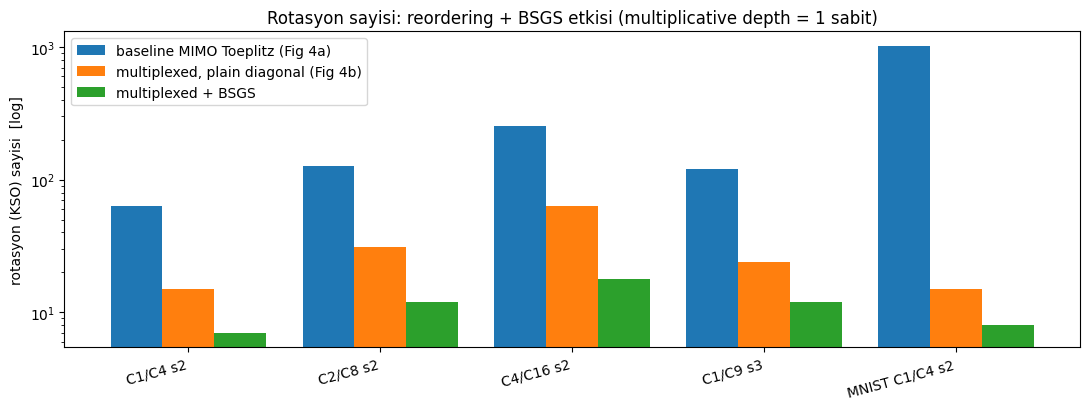

C1/C4 s2         baseline=   63  plain=  15  bsgs=   7
C2/C8 s2         baseline=  127  plain=  31  bsgs=  12
C4/C16 s2        baseline=  255  plain=  63  bsgs=  18
C1/C9 s3         baseline=  120  plain=  24  bsgs=  12
MNIST C1/C4 s2   baseline= 1023  plain=  15  bsgs=   8


In [9]:
!/content/fhe310/bin/python /content/mimo_mux_fhe.py --mode counts
import json, numpy as np, matplotlib.pyplot as plt
data = json.load(open("/content/rotation_compare.json"))
names = [d["name"] for d in data]
base = [d["baseline"] for d in data]; plain = [d["plain"] for d in data]; bsgs = [d["bsgs"] for d in data]
x = np.arange(len(names)); w = 0.27
fig, ax = plt.subplots(figsize=(11,4.2))
ax.bar(x-w, base, w, label="baseline MIMO Toeplitz (Fig 4a)")
ax.bar(x,   plain, w, label="multiplexed, plain diagonal (Fig 4b)")
ax.bar(x+w, bsgs, w, label="multiplexed + BSGS")
ax.set_yscale("log"); ax.set_ylabel("rotasyon (KSO) sayisi  [log]")
ax.set_xticks(x); ax.set_xticklabels(names, rotation=15, ha="right")
ax.set_title("Rotasyon sayisi: reordering + BSGS etkisi (multiplicative depth = 1 sabit)")
ax.legend(); plt.tight_layout(); plt.show()
for d in data: print(f"{d['name']:16s} baseline={d['baseline']:>5}  plain={d['plain']:>4}  bsgs={d['bsgs']:>4}")

## Görseller

MNIST çok-kanallı çıktının plaintext ve homomorfik kanallarını (ve farkını) yan yana çiziyorum.

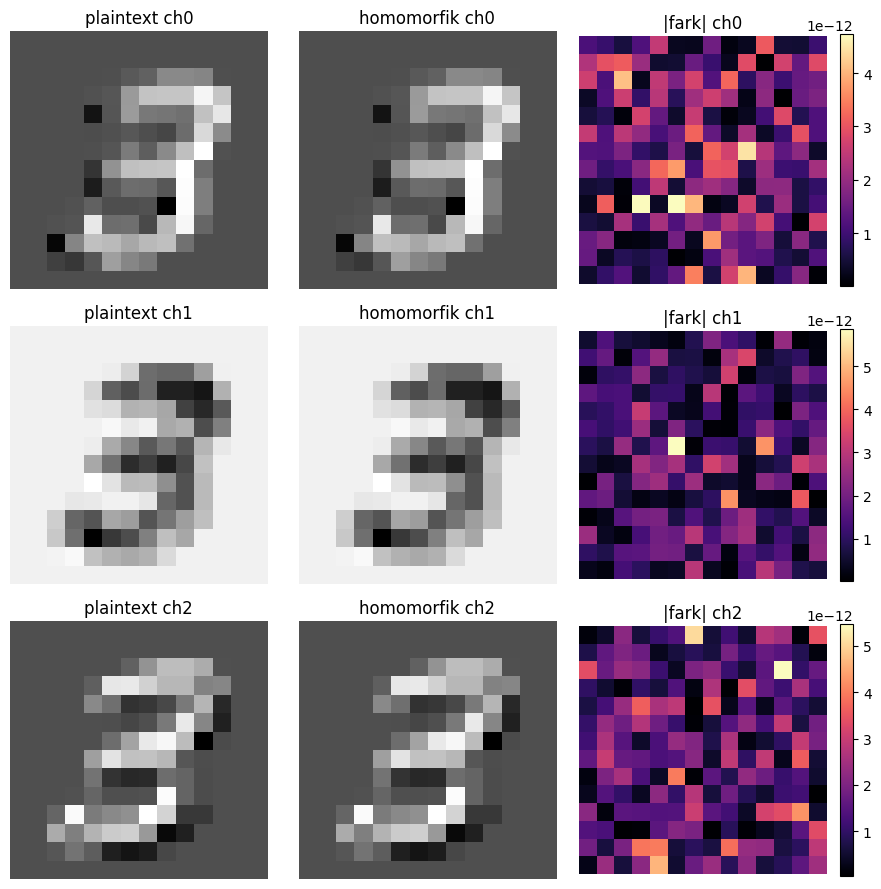

max |fark| = 5.859757123971576e-12


In [10]:
import numpy as np, matplotlib.pyplot as plt
img = np.load("/content/mnist_input.npy")        # (1,28,28)
exp = np.load("/content/mnist_expected.npy")      # (Co,Ho,Wo)
dec = np.load("/content/mnist_decrypted.npy")     # (Co,Ho,Wo)
Co = exp.shape[0]; show = min(Co, 3)
fig, ax = plt.subplots(show, 3, figsize=(9, 3.0*show))
ax = np.atleast_2d(ax)
for c in range(show):
    ax[c,0].imshow(exp[c], cmap="gray"); ax[c,0].set_title(f"plaintext ch{c}")
    ax[c,1].imshow(dec[c], cmap="gray"); ax[c,1].set_title(f"homomorfik ch{c}")
    im = ax[c,2].imshow(np.abs(exp[c]-dec[c]), cmap="magma"); ax[c,2].set_title(f"|fark| ch{c}")
    fig.colorbar(im, ax=ax[c,2], fraction=0.046)
    for a in ax[c]: a.axis("off")
plt.tight_layout(); plt.show()
print("max |fark| =", float(np.abs(exp-dec).max()))

## PyTorch çapraz kontrolü

Aynı çok-kanallı strided convolution'ı `torch.nn.functional.conv2d` ile hesaplayıp hem Toeplitz plaintext hem de homomorfik sonuçla karşılaştırıyorum (Colab'ın kendi Python'ında).

In [11]:
import numpy as np
try:
    import torch, torch.nn.functional as F
    img = np.load("/content/mnist_input.npy"); W = np.load("/content/mnist_weight.npy")
    ref = np.load("/content/mnist_expected.npy"); he = np.load("/content/mnist_decrypted.npy")
    xt = torch.tensor(img[None], dtype=torch.float64)          # (1,Ci,H,W)
    wt = torch.tensor(W, dtype=torch.float64)                  # (Co,Ci,kH,kW)
    out = F.conv2d(xt, wt, stride=2, padding=1).numpy()[0]     # (Co,Ho,Wo)
    print("PyTorch == NumPy(Toeplitz):", np.allclose(out, ref, atol=1e-6), f"| max fark {np.abs(out-ref).max():.2e}")
    print("PyTorch == homomorfik     :", np.allclose(out, he,  atol=1e-2), f"| max fark {np.abs(out-he).max():.2e}")
except Exception as e:
    print("torch atlandi:", e)

PyTorch == NumPy(Toeplitz): True | max fark 4.44e-16
PyTorch == homomorfik     : True | max fark 5.86e-12


## Parametre notu

- **Multiplicative depth = 1:** MIMO ve strided dahil tüm durumlarda tek `EvalMult` zinciri; mask-and-collect ağırlığa gömülü. BSGS'te de her terim tek plaintext çarpımı olduğundan depth 1 sabit.
- **ScalingModSize = 50:** ≈50-bit hassasiyet, MAE genelde 1e-11…1e-3 aralığında (kanal/stride büyüdükçe biriken gürültüyle artar).
- **Slot sayısı S:** multiplexed Toeplitz'in kareye gömülmüş boyutunun üzerindeki ilk 2'nin kuvveti.
- **Reordering kazancı:** stride yoksa ($g=1$) multiplexed = baseline ; stride arttıkça diagonal sayısı ve dolayısıyla rotasyon dramatik düşer (ör. MNIST s=2, $C_o=4$: 1023 → 15 → BSGS ile ~8).

## Özet

SISO Toeplitz + diagonal altyapısı **çok-kanallı (MIMO)** biçime ve Orion'un **single-shot multiplexed packing** yapısına taşındı. Mask-and-collect adımı ağırlık matrisine ön-işleme ile gömülerek **strided convolution dahil tüm işlem multiplicative depth = 1**'de tutuldu; satır reordering ile seyrek diagonaller yoğunlaştırılıp **rotasyon (KSO) sayısı minimize edildi** ve ek olarak BSGS ile daha da düşürüldü. Şifreli çıktılar de-multiplex edildikten sonra NumPy ve PyTorch referanslarıyla CKKS gürültü seviyesinde eşleşti.